We begin by importing our dataset from kaggle.

In [2]:
import kagglehub


path = kagglehub.dataset_download("jessicali9530/caltech256")
print("Path to dataset files:", path)



100%|██████████| 2.12G/2.12G [00:21<00:00, 106MB/s] 

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/jessicali9530/caltech256/versions/2


In [3]:
import os
dataset_dir = os.path.join(path, "256_ObjectCategories")


We have downloaded and successfully accessed the directory where the data is stored. This is needed for use later on while calling the model function

In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import transforms, datasets

class BasicBlock(nn.Module):
    def __init__(self,in_channels,out_channels,stride=1):
        super().__init__()
        self.conv1 = nn.Conv2d(in_channels,out_channels,kernel_size=3,stride=stride,padding=1,bias=False)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels,out_channels,kernel_size=3,stride=1,padding=1,bias=False)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU(inplace=True)
        self.shortcut = nn.Sequential()

        if stride != 1 or in_channels != out_channels:
            self.shortcut = nn.Sequential(nn.Conv2d(in_channels,out_channels,kernel_size=1,stride=stride,bias=False),nn.BatchNorm2d(out_channels))

    def forward(self,x):
        identity = self.shortcut(x)
        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)
        out = self.conv2(out)
        out = self.bn2(out)
        out += identity
        out = self.relu(out)
        return out

In [5]:
class ResNet18(nn.Module):
    def __init__(self,num_classes):
        super().__init__()

        self.in_channels = 64

        self.conv1 = nn.Conv2d(3,64,kernel_size=7,stride=2,padding=3,bias=False)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu = nn.ReLU(inplace=True)
        self.maxpool = nn.MaxPool2d(kernel_size=3,stride=2,padding=1)

        self.layer1 = self._make_layer(64,2,stride=1)
        self.layer2 = self._make_layer(128,2,stride=2)
        self.layer3 = self._make_layer(256,2,stride=2)
        self.layer4 = self._make_layer(512,2,stride=2)

        self.avgpool = nn.AdaptiveAvgPool2d((1,1))
        self.fc = nn.Linear(512,num_classes)

    def _make_layer(self,out_channels,blocks,stride):
        layers = [BasicBlock(self.in_channels,out_channels,stride)]
        self.in_channels = out_channels
        for _ in range(1,blocks):
            layers.append(BasicBlock(self.in_channels,out_channels))

        return nn.Sequential(*layers)

    def forward(self,x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu(x)
        x = self.maxpool(x)

        x = self.layer1(x)
        x = self.layer2(x)
        x = self.layer3(x)
        x = self.layer4(x)

        x = self.avgpool(x)
        x = torch.flatten(x,1)
        x = self.fc(x)
        return x


In [ ]:
if __name__ == '__main__':

    data_directory = dataset_dir
    batch_sizee = 32

    epochs = 20

    learning_rate = 0.002

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    print(f"Executing pipeline on device accelerator: {device}")

    data_transforms = transforms.Compose([
        transforms.Resize((256,256)),
        transforms.RandomCrop((224,224)),
        transforms.RandomHorizontalFlip(p=0.5),
        transforms.RandomRotation(degrees=15),
        transforms.ColorJitter(brightness=0.2,contrast=0.2,saturation=0.2,hue=0.1),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485,0.456,0.406],std=[0.229,0.224,0.225])
    ])

    full_dataset = datasets.ImageFolder(root=data_directory,transform=data_transforms)

    num_classes = len(full_dataset.classes)

    #split the dataset into 80/20 train/test
    train_size = int(0.8 * len(full_dataset))
    test_size = len(full_dataset) - train_size

    train_dataset,test_dataset = random_split(full_dataset,[train_size,test_size])

    train_loader = DataLoader(train_dataset,batch_size=batch_sizee,shuffle=True)
    test_loader = DataLoader(test_dataset,batch_size=batch_sizee,shuffle=False)

    model = ResNet18(num_classes=num_classes).to(device)

    criterion = nn.CrossEntropyLoss()

    optimizer = optim.SGD(
        model.parameters(),
        lr=learning_rate,
        momentum=0.9,
        weight_decay=1e-4
    )

    #Learning rate scheduling suggestion from LLM due to earlier overfitting on train set
    scheduler = optim.lr_scheduler.StepLR(
        optimizer,
        step_size=30,
        gamma=0.1
    )

    for epoch in range(epochs):

        model.train()

        running_loss = 0.0
        correct = 0
        total = 0

        for images,labels in train_loader:

            images,labels = images.to(device),labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs,labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _,predicted = torch.max(outputs,1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

      
        scheduler.step()

        train_accuracy = 100 * correct / total

        current_lr = optimizer.param_groups[0]['lr']

        print(
            f"Epoch [{epoch+1}/{epochs}] "
            f"Loss: {running_loss/len(train_loader):.4f} "
            f"Train Acc: {train_accuracy:.2f}% "
            f"LR: {current_lr:.6f}"
        )

    model.eval()

    correcte = 0
    totale = 0

    with torch.no_grad():

        for images,labels in test_loader:

            images = images.to(device)
            labels = labels.to(device)
            outputs = model(images)
            _,predicted = torch.max(outputs,dim=1)

            totale += labels.size(0)
            correcte += (predicted == labels).sum().item()

    test_accuracy = 100 * correcte / totale
    print(f"Test Accuracy: {test_accuracy:.2f}%")
    torch.save({
        'epoch': epochs,
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
    },"resnet18_caltech256.pth")

    print("Model weights saved as resnet18_caltech256.pth")

Executing pipeline on device accelerator: cuda
Epoch [1/20] Loss: 4.9603 Train Acc: 8.40% LR: 0.002000
Epoch [2/20] Loss: 4.3537 Train Acc: 14.54% LR: 0.002000
Epoch [3/20] Loss: 3.9539 Train Acc: 19.51% LR: 0.002000
Epoch [4/20] Loss: 3.6261 Train Acc: 24.18% LR: 0.002000
Epoch [5/20] Loss: 3.3441 Train Acc: 28.63% LR: 0.002000
Epoch [6/20] Loss: 3.0863 Train Acc: 32.43% LR: 0.002000
Epoch [7/20] Loss: 2.8879 Train Acc: 35.85% LR: 0.002000
Epoch [8/20] Loss: 2.7147 Train Acc: 38.95% LR: 0.002000
Epoch [9/20] Loss: 2.5366 Train Acc: 42.52% LR: 0.002000
Epoch [10/20] Loss: 2.3974 Train Acc: 45.13% LR: 0.002000
Epoch [11/20] Loss: 2.2779 Train Acc: 47.38% LR: 0.002000
Epoch [12/20] Loss: 2.1444 Train Acc: 49.91% LR: 0.002000
Epoch [13/20] Loss: 2.0223 Train Acc: 52.17% LR: 0.002000
Epoch [14/20] Loss: 1.9323 Train Acc: 54.17% LR: 0.002000
Epoch [15/20] Loss: 1.8270 Train Acc: 56.19% LR: 0.002000
Epoch [16/20] Loss: 1.7450 Train Acc: 57.78% LR: 0.002000
Epoch [17/20] Loss: 1.6590 Train Ac

In [8]:
from google.colab import files
files.download("resnet18_caltech256.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Generating Grad-CAM for CORRECT predictions...


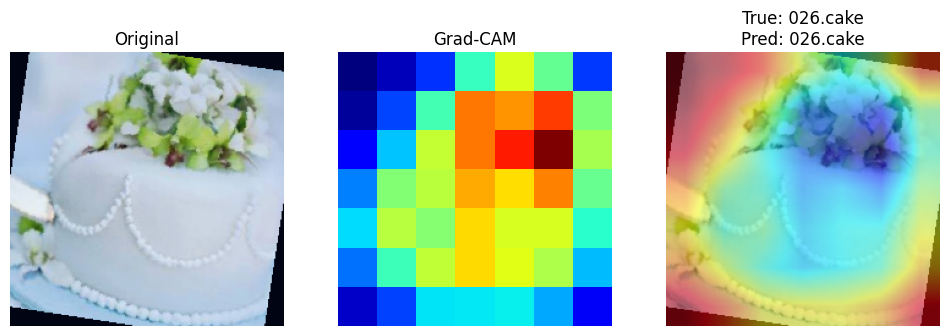

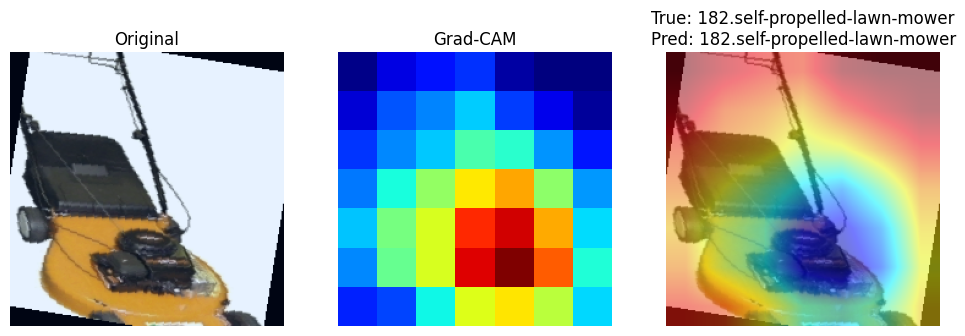

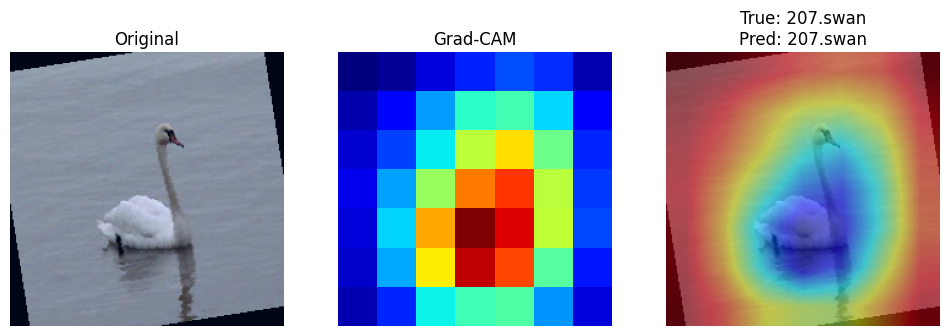

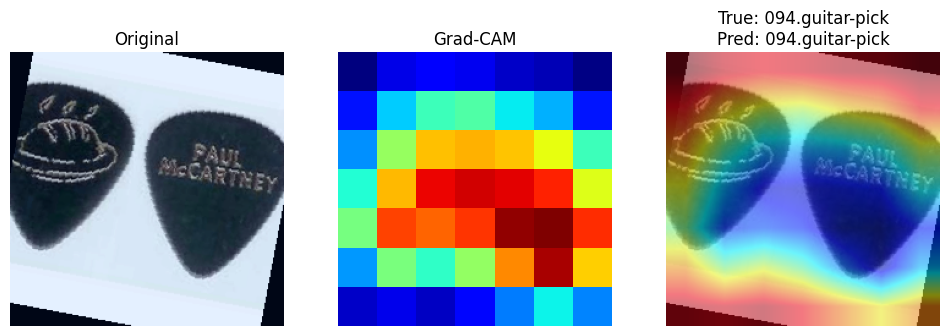

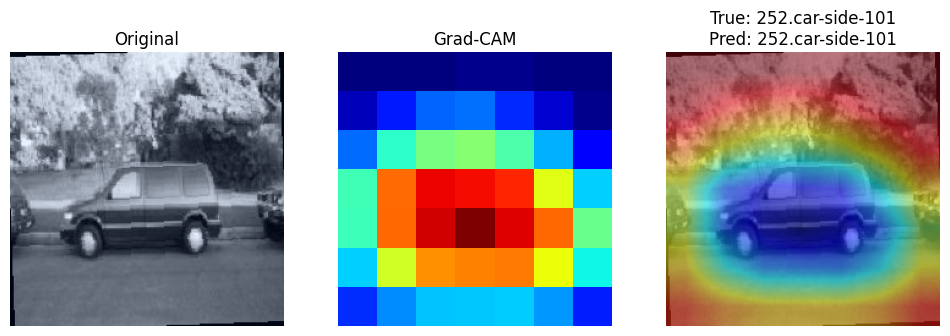

Generating Grad-CAM for INCORRECT predictions...


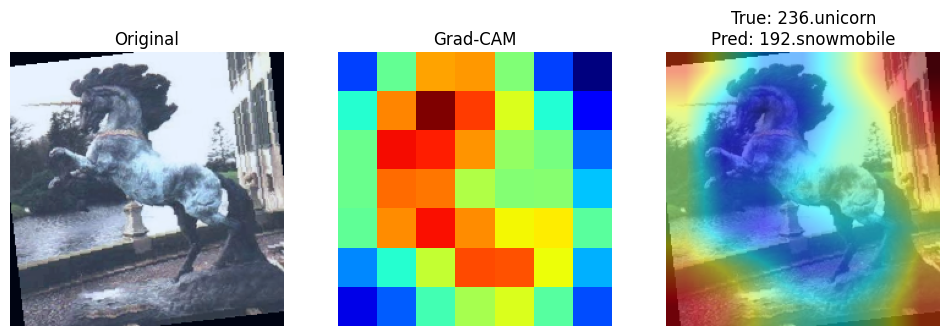

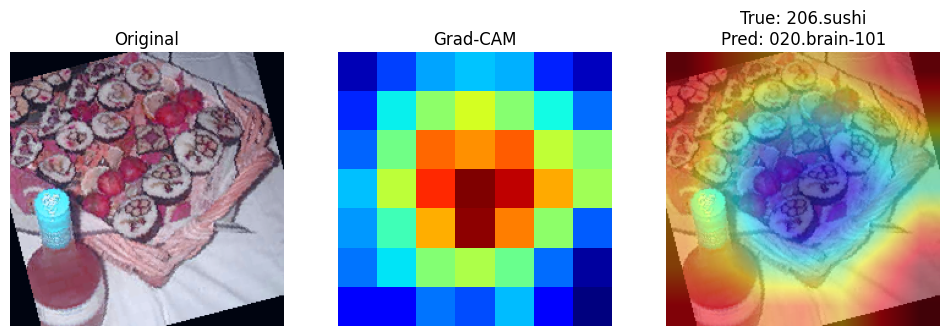

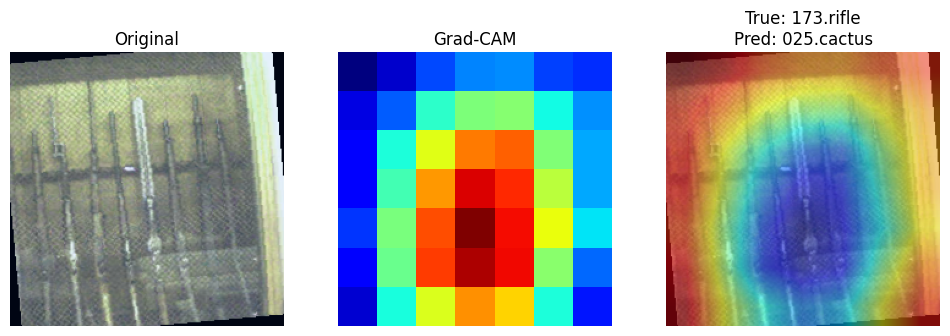

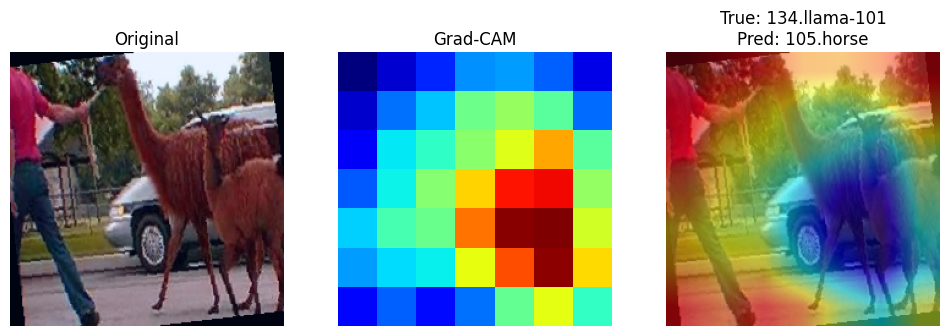

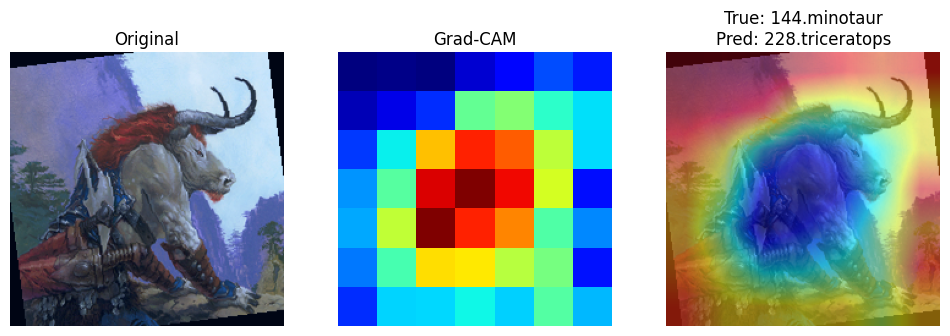

In [ ]:
import torch
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import cv2

class GradCAM:
    def __init__(self, model, target_layer):
        self.model = model
        self.target_layer = target_layer
        self.activations = None
        self.gradients = None

        self.target_layer.register_forward_hook(self.forward_hook)
        self.target_layer.register_full_backward_hook(self.backward_hook)

    def forward_hook(self, module, input, output):
        self.activations = output.detach()

    def backward_hook(self, module, grad_input, grad_output):
        self.gradients = grad_output[0].detach()

    def generate(self, input_tensor, class_idx=None):
        self.model.eval()

        output = self.model(input_tensor)

        if class_idx is None:
            class_idx = output.argmax(dim=1).item()

        self.model.zero_grad()

        score = output[:, class_idx]
        score.backward()

        weights = self.gradients.mean(dim=(2, 3), keepdim=True)
        cam = torch.sum(weights * self.activations, dim=1).squeeze()

        cam = F.relu(cam)
        cam = cam - cam.min()
        cam = cam / (cam.max() + 1e-8)

        return cam.cpu().numpy(), class_idx


#LLM help was used in certain parts of the following function
def visualize_gradcam(model, target_layer, image_tensor, class_names, true_label, pred_label):
    gradcam = GradCAM(model, target_layer)
    cam, _ = gradcam.generate(image_tensor)

    image = image_tensor.squeeze().permute(1, 2, 0).cpu().numpy()
    image = (image - image.min()) / (image.max() - image.min() + 1e-8)

    heatmap = cv2.resize(cam, (image.shape[1], image.shape[0]))
    heatmap = np.uint8(255 * heatmap)
    heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

    overlay = heatmap.astype(np.float32) / 255 + image.astype(np.float32)
    overlay = overlay / (overlay.max() + 1e-8)

    plt.figure(figsize=(12, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(image)
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(cam, cmap="jet")
    plt.title("Grad-CAM")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(overlay)
    plt.title(f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}")
    plt.axis("off")

    plt.show()



correct_samples = []
incorrect_samples = []

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        preds = torch.argmax(outputs, dim=1)

        for i in range(images.size(0)):
            img = images[i].unsqueeze(0)
            true = labels[i].item()
            pred = preds[i].item()

            if pred == true:
                correct_samples.append((img, true, pred))
            else:
                incorrect_samples.append((img, true, pred))


# ---------------------------
# RUN GRAD-CAM ON BOTH SETS
# ---------------------------
target_layer = model.layer4[-1]

print("Generating Grad-CAM for CORRECT predictions...")
for img, true, pred in correct_samples[:5]:
    visualize_gradcam(model, target_layer, img, full_dataset.classes, true, pred)

print("Generating Grad-CAM for INCORRECT predictions...")
for img, true, pred in incorrect_samples[:5]:
    visualize_gradcam(model, target_layer, img, full_dataset.classes, true, pred)